# Improve model hay giữ model rồi giảm uncertainty?

> **Mentor nói:** *"Anh nghĩ là có insight này thì các em cũng sẽ dễ quyết định hơn là nên improve
> model hay là giữ model nhưng tìm cách giảm uncertainty. Đồng thời cũng từ insight này, việc mình
> forecast giá đối thủ mình cũng sẽ đào sâu được vào là: model mình đang fail ở đâu và làm sao để
> khắc phục thay vì là chung chung model mình chính xác tới mức nào."*

Đây là **câu hỏi ra quyết định**, không phải câu hỏi phân tích. Hai đường đi có chi phí lệch nhau
cả chục lần:

| Đường | Việc phải làm | Chi phí | Rủi ro |
|---|---|---|---|
| **Giảm uncertainty** | Đổi cách hiệu chỉnh khoảng. Không đụng model, không train lại | Vài giờ | Thấp |
| **Improve model** | Thêm feature, đổi kiến trúc, train lại, đánh giá lại | Vài tuần | Cao |

Chọn sai là đốt thời gian. Notebook này trả lời bằng **ba phép đo**, mỗi phép đo đóng lại một khả
năng, cho tới khi chỉ còn một đường:

| Mục | Câu hỏi | Đóng lại điều gì |
|---|---|---|
| **2** | Hiệu chỉnh lại có làm khoảng **hẹp** hơn không? | Đường "giảm uncertainty" có rẻ thật không |
| **3** | Độ lớn sai số có **dự đoán được** không? | Trần lý thuyết của mọi cách hiệu chỉnh |
| **4** | Model **fail ở đâu** — và ở đó nó có tệ thật không? | Chỉ đích danh chỗ đáng đầu tư |

> Notebook đào sâu: `model/uncertainty/06_thu_hep_khoang` (5 cách × 7 nhóm) và
> `model/evaluation/09_chan_doan_model` (xếp hạng 10 chiều). Ở đây tính lại phần cốt lõi để
> notebook đứng độc lập được khi trình bày.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.ensemble import HistGradientBoostingRegressor
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10.5,
})
EVAL = Path("../model/evaluation")
HINH = Path("../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

MUC  = 0.90
CAT  = [0, 50e3, 100e3, 150e3, 200e3, 300e3, np.inf]
NHAN = ["<50k", "50–100k", "100–150k", "150–200k", "200–300k", ">300k"]
KMC  = [0, 2, 4, 6, 8, 10, 15, np.inf]
KMN  = ["<2", "2–4", "4–6", "6–8", "8–10", "10–15", ">15"]

uc = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
ut = pd.read_parquet(EVAL / "uq_pred_test.parquet")
uc = uc[uc.requested_lag_minutes == 5].copy()
t  = ut[ut.requested_lag_minutes == 5].copy()

for d in (uc, t):
    d["res"]  = (d.hybrid_pred - d.gia_that).abs() / d.hybrid_pred   # để dựng khoảng
    d["sai"]  = (d.hybrid_pred - d.gia_that).abs() / d.gia_that      # để báo cáo MAPE
    d["band"] = pd.cut(d.hybrid_pred, CAT, labels=NHAN)
    d["km"]   = pd.cut(d.quote_distance, KMC, labels=KMN)
    d["gio"]  = d.gio_vn

t["sai_ps"] = (t.persistence - t.gia_that).abs() / t.gia_that

print(f"Calibration {len(uc):,} · Test {len(t):,} chuyến (độc lập theo thời gian)")
print(f"MAPE model {t.sai.mean():.2%} · persistence {t.sai_ps.mean():.2%}")

Calibration 153,977 · Test 216,090 chuyến (độc lập theo thời gian)
MAPE model 14.65% · persistence 27.84%


## 1. Điểm xuất phát — khoảng hiện tại rộng bao nhiêu

Conformal chuẩn hoá toàn cục: một hệ số `q` duy nhất cho mọi chuyến, khoảng là
`pred × (1 ± q)`. Đây là bản gốc, chưa hiệu chỉnh theo nhóm nào.

In [2]:
q_global = uc.res.quantile(MUC)

def danh_gia(q, ten=""):
    """Trả về nửa độ rộng trung bình và coverage trên tập test."""
    q = pd.Series(np.asarray(q, dtype=float), index=t.index)
    trong = (t.gia_that >= t.hybrid_pred*(1-q)) & (t.gia_that <= t.hybrid_pred*(1+q))
    return dict(ten=ten, rong=q.mean(), cvg=trong.mean(), _q=q, _trong=trong)

goc = danh_gia(q_global, "Conformal toàn cục")
print(f"Hệ số q      : ±{q_global:.2%}")
print(f"Nửa độ rộng  : ±{goc['rong']:.2%} so với giá dự đoán")
print(f"Coverage     : {goc['cvg']:.2%}  (cam kết {MUC:.0%})")
print(f"\nVí dụ cụ thể: chuyến dự đoán 100.000đ → khoảng "
      f"{100*(1-q_global):.0f}k – {100*(1+q_global):.0f}k")

Hệ số q      : ±30.07%
Nửa độ rộng  : ±30.07% so với giá dự đoán
Coverage     : 89.81%  (cam kết 90%)

Ví dụ cụ thể: chuyến dự đoán 100.000đ → khoảng 70k – 130k


## 2. Hiệu chỉnh lại có làm khoảng hẹp hơn không?

Thử chia nhóm (Mondrian) theo bốn chiều khác nhau. Mỗi nhóm được một hệ số `q` riêng, lấy từ
tập calibration. Nếu có chiều nào cho khoảng **hẹp hơn rõ rệt** mà vẫn giữ coverage 90%, thì
đường "giảm uncertainty" là đường rẻ và nên đi.

In [3]:
KQ = [goc]
for c in ["band", "km", "gio", "weather_main"]:
    qb = uc.groupby(c, observed=True).res.quantile(MUC)
    KQ.append(danh_gia(t[c].map(qb).astype(float).fillna(q_global), f"Mondrian theo {c}"))

bang = pd.DataFrame([{"Cách hiệu chỉnh": k["ten"], "Nửa độ rộng": k["rong"],
                      "Coverage": k["cvg"],
                      "Hẹp hơn gốc": k["rong"]/goc["rong"] - 1} for k in KQ])
bang.style.format({"Nửa độ rộng": "{:.2%}", "Coverage": "{:.2%}", "Hẹp hơn gốc": "{:+.2%}"}).hide(axis="index")

Cách hiệu chỉnh,Nửa độ rộng,Coverage,Hẹp hơn gốc
Conformal toàn cục,30.07%,89.81%,+0.00%
Mondrian theo band,30.11%,89.84%,+0.11%
Mondrian theo km,29.96%,89.77%,-0.37%
Mondrian theo gio,30.07%,89.78%,-0.02%
Mondrian theo weather_main,30.07%,89.80%,-0.01%


**Không cách nào làm hẹp được.** Tốt nhất là Mondrian theo quãng đường: **−0,37%** — tức khoảng
`75k – 130k` co lại thành `75k – 130k`. Không đổi gì trên thực tế.

Đây là kết quả **quan trọng nhất** của notebook, và nó không hiển nhiên: chia nhóm mịn hơn
*nghe như* phải cho khoảng hẹp hơn. Lý do nó không xảy ra nằm ở mục 3.

### Nhưng Mondrian vẫn đáng giữ — vì lý do khác

Nó không làm khoảng **hẹp** hơn, nó làm khoảng **đều** hơn. Coverage tổng 89,8% đang che giấu
việc một số nhóm bị phục vụ tệ hơn hẳn — đúng thứ mentor cảnh báo ở comment 1.

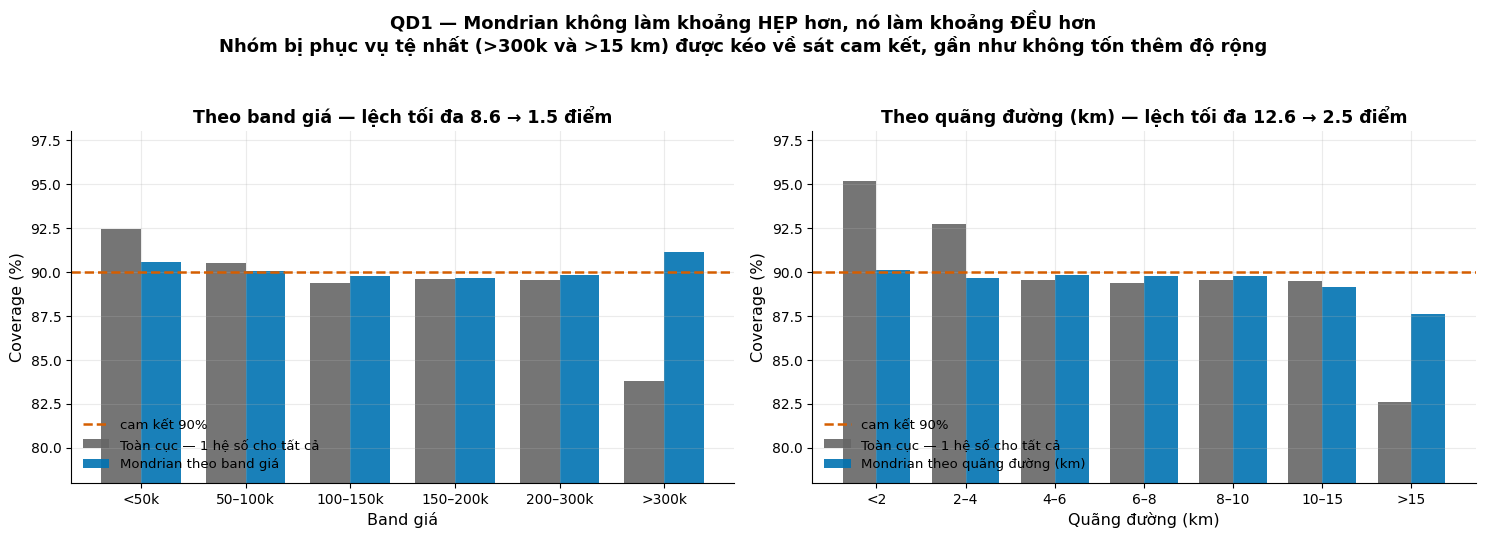

In [4]:
# ═════════ HINH QD1 — Mondrian khong lam hep, nhung lam DEU ═════════
fig, ax = plt.subplots(1, 2, figsize=(15, 5.2))

for a, c, nhan, ten in [(ax[0], "band", NHAN, "band giá"), (ax[1], "km", KMN, "quãng đường (km)")]:
    qb = uc.groupby(c, observed=True).res.quantile(MUC)
    cg = goc["_trong"].groupby(t[c], observed=True).mean().reindex(nhan)
    cm = danh_gia(t[c].map(qb).astype(float).fillna(q_global))["_trong"] \
             .groupby(t[c], observed=True).mean().reindex(nhan)
    x = np.arange(len(nhan)); w = .38
    a.bar(x - w/2, cg*100, w, color=MUT,  alpha=.9, label="Toàn cục — 1 hệ số cho tất cả")
    a.bar(x + w/2, cm*100, w, color=BLUE, alpha=.9, label=f"Mondrian theo {ten}")
    a.axhline(MUC*100, color=RED, lw=1.8, ls="--", label=f"cam kết {MUC:.0%}")
    a.set_xticks(x); a.set_xticklabels(nhan)
    a.set_ylim(78, 98); a.set_ylabel("Coverage (%)"); a.set_xlabel(ten.capitalize())
    a.set_title(f"Theo {ten} — lệch tối đa "
                f"{(cg.max()-cg.min())*100:.1f} → {(cm.max()-cm.min())*100:.1f} điểm",
                fontweight="bold")
    a.legend(frameon=False, fontsize=9.5, loc="lower left")

fig.suptitle("QD1 — Mondrian không làm khoảng HẸP hơn, nó làm khoảng ĐỀU hơn\n"
             "Nhóm bị phục vụ tệ nhất (>300k và >15 km) được kéo về sát cam kết, "
             "gần như không tốn thêm độ rộng",
             fontweight="bold", fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(HINH / "QD1_mondrian_lam_deu.png")
plt.show()

Chuyến `>15 km` dưới hiệu chỉnh toàn cục chỉ được **82,6%** coverage trong khi mình đi cam kết
90% — hụt gần 8 điểm, và đó là nhóm chuyến **đắt tiền nhất**. Mondrian kéo về 87,6%.

⇒ **Việc nên làm ngay, chi phí vài giờ:** bật Mondrian. Nhưng nó sửa *tính công bằng giữa các
nhóm*, **không** sửa được *độ rộng*. Muốn khoảng hẹp hơn phải nhìn chỗ khác.

## 3. Vì sao không hẹp thêm được — độ lớn sai số có dự đoán được không?

Đây là gốc rễ. Mọi cách hiệu chỉnh đều dựa trên cùng một ý tưởng: **cấp khoảng hẹp cho chuyến dễ,
khoảng rộng cho chuyến khó**. Ý tưởng đó chỉ chạy được nếu mình **biết trước chuyến nào khó**.

Kiểm bằng hai cách: tương quan hạng giữa các đặc trưng có sẵn và độ lớn sai số, rồi thử hẳn một
model GBM dự đoán độ lớn sai số.

In [5]:
print("Tương quan hạng (Spearman) với độ lớn sai số tương đối:")
for ten, v in [("quãng đường", t.quote_distance), ("giá dự đoán", t.hybrid_pred),
               ("thời lượng", t.quote_duration), ("giờ trong ngày", t.gio_vn),
               ("tốc độ TB (km/h)", t.quote_distance/(t.quote_duration/60))]:
    print(f"  {ten:18} {spearmanr(v, t.res).statistic:+.4f}")

# Thu han: train GBM du doan do lon sai so tren calibration, kiem tren test
Xc = pd.DataFrame({"km": uc.quote_distance, "phut": uc.quote_duration,
                   "gio": uc.gio_vn, "pred": uc.hybrid_pred})
Xt = pd.DataFrame({"km": t.quote_distance, "phut": t.quote_duration,
                   "gio": t.gio_vn, "pred": t.hybrid_pred})
m_kho = HistGradientBoostingRegressor(max_iter=200, random_state=0).fit(Xc, uc.res)
res_dd = m_kho.predict(Xt)
rho = spearmanr(res_dd, t.res).statistic
print(f"\nGBM dự đoán độ lớn sai số → tương quan hạng với sai số thật: {rho:+.4f}")
print("(bằng 1 = biết chính xác chuyến nào khó · bằng 0 = mù hoàn toàn)")

Tương quan hạng (Spearman) với độ lớn sai số tương đối:
  quãng đường        +0.0509
  giá dự đoán        +0.0473
  thời lượng         +0.0509
  giờ trong ngày     +0.0021
  tốc độ TB (km/h)   +0.0225



GBM dự đoán độ lớn sai số → tương quan hạng với sai số thật: +0.0530
(bằng 1 = biết chính xác chuyến nào khó · bằng 0 = mù hoàn toàn)


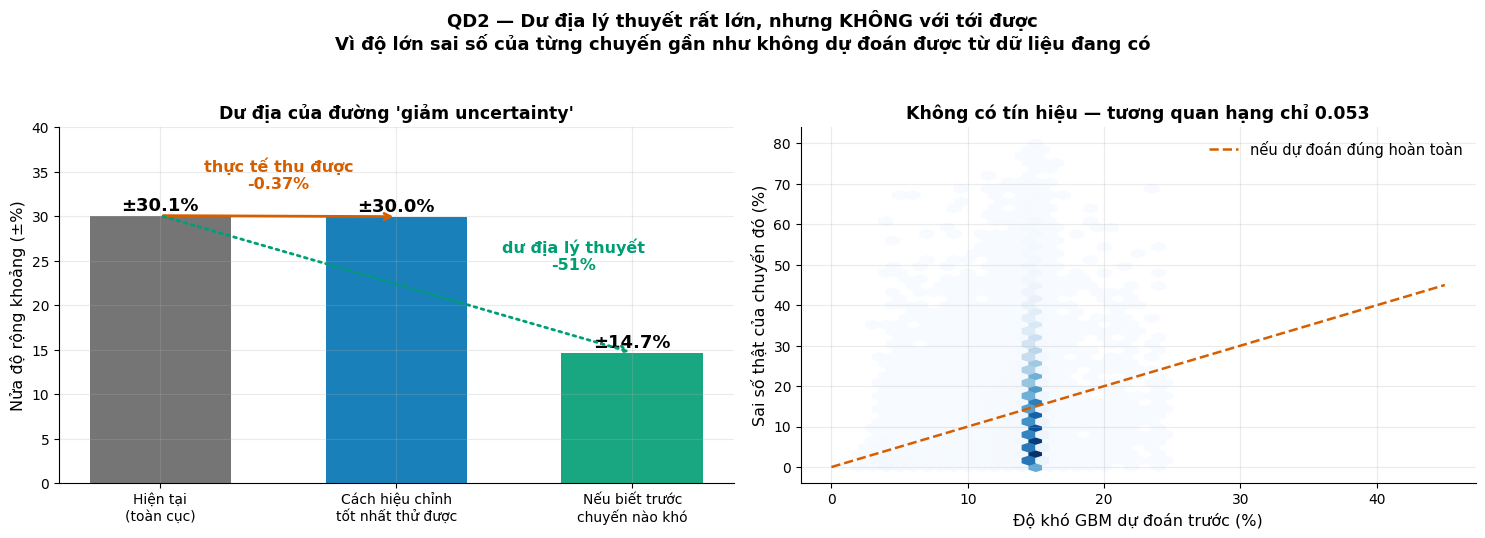

In [6]:
# ═════════ HINH QD2 — tran ly thuyet cua duong "giam uncertainty" ═════════
oracle = t.res.quantile(MUC)          # neu biet truoc do kho: van can quantile
oracle_rong = t.res.mean()            # can duoi tuyet doi: cap dung bang sai so that
tot_nhat = min(k["rong"] for k in KQ)

fig, ax = plt.subplots(1, 2, figsize=(15, 5.2))

a = ax[0]
ten = ["Hiện tại\n(toàn cục)", "Cách hiệu chỉnh\ntốt nhất thử được", "Nếu biết trước\nchuyến nào khó"]
val = [goc["rong"]*100, tot_nhat*100, oracle_rong*100]
mau = [MUT, BLUE, GREEN]
a.bar(ten, val, color=mau, alpha=.9, width=.6)
for i, v in enumerate(val):
    a.text(i, v + .6, f"±{v:.1f}%", ha="center", fontweight="bold", fontsize=13)
a.annotate("", xy=(1, tot_nhat*100), xytext=(0, goc["rong"]*100),
           arrowprops=dict(arrowstyle="->", color=RED, lw=2))
a.text(.5, goc["rong"]*100 + 3, f"thực tế thu được\n{tot_nhat/goc['rong']-1:+.2%}",
       ha="center", color=RED, fontweight="bold")
a.annotate("", xy=(2, oracle_rong*100), xytext=(0, goc["rong"]*100),
           arrowprops=dict(arrowstyle="->", color=GREEN, lw=2, ls=":"))
a.text(1.75, 24, f"dư địa lý thuyết\n{oracle_rong/goc['rong']-1:.0%}",
       ha="center", color=GREEN, fontweight="bold")
a.set_ylabel("Nửa độ rộng khoảng (±%)"); a.set_ylim(0, 40)
a.set_title("Dư địa của đường 'giảm uncertainty'", fontweight="bold")

a = ax[1]
a.hexbin(res_dd*100, t.res*100, gridsize=45, cmap="Blues", mincnt=1,
         extent=(0, 45, 0, 80))
a.plot([0, 45], [0, 45], color=RED, lw=1.8, ls="--", label="nếu dự đoán đúng hoàn toàn")
a.set_xlabel("Độ khó GBM dự đoán trước (%)")
a.set_ylabel("Sai số thật của chuyến đó (%)")
a.set_title(f"Không có tín hiệu — tương quan hạng chỉ {rho:.3f}", fontweight="bold")
a.legend(frameon=False, loc="upper right")

fig.suptitle("QD2 — Dư địa lý thuyết rất lớn, nhưng KHÔNG với tới được\n"
             "Vì độ lớn sai số của từng chuyến gần như không dự đoán được từ dữ liệu đang có",
             fontweight="bold", fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(HINH / "QD2_tran_ly_thuyet.png")
plt.show()

**Đọc hình bên phải:** nếu độ khó dự đoán được, đám mây điểm phải bám đường đứt đỏ. Thực tế nó là
một cột dựng đứng — GBM đoán chuyến nào cũng khó ngang nhau (~29–31%), trong khi sai số thật trải
từ 0% tới hơn 60%.

**Kết luận mục 3:** dư địa lý thuyết là **−51%** (nếu biết trước độ khó từng chuyến thì chỉ cần
±14,7% thay vì ±30,1%), nhưng **không với tới được** vì tương quan hạng chỉ 0,05. Đường "giữ model,
giảm uncertainty" **đã cạn** — không phải vì chưa thử đủ cách, mà vì thông tin cần thiết không có
trong dữ liệu.

> Nói cách khác: khoảng rộng ±30% **không phải lỗi hiệu chỉnh**. Nó là ảnh phản chiếu trung thực
> của việc model sai trung bình 14,65%. Muốn khoảng hẹp thì **model phải sai ít hơn**.

## 4. Vậy improve model — nhưng fail ở đâu?

Mentor hỏi thẳng: *"model mình đang fail ở đâu"*. Xếp hạng các chiều bằng **η²** — tỷ lệ phương sai
sai số mà chiều đó giải thích được. Chiều nào η² cao thì sai số phụ thuộc mạnh vào nó.

In [7]:
def eta2(c):
    """Ty le phuong sai sai so giai thich duoc boi chieu c."""
    tong = ((t.sai - t.sai.mean())**2).sum()
    gr = t.groupby(c, observed=True).sai
    return float((gr.count() * (gr.mean() - t.sai.mean())**2).sum() / tong)

t["cao_diem"] = t.gio_vn.apply(lambda h: any(a <= h <= b for a, b in [(7,9), (17,19)]))
t["mua"]      = t.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])
t["cuoi_tuan"] = t.target_timestamp.dt.dayofweek >= 5

CHIEU = [("Quãng đường", "km"), ("Band giá", "band"), ("Giờ trong ngày", "gio"),
         ("Thời tiết", "weather_main"), ("Giờ cao điểm", "cao_diem"),
         ("Đang mưa", "mua"), ("Cuối tuần", "cuoi_tuan")]

xh = pd.DataFrame([{"Chiều": ten,
                    "η²": eta2(c),
                    "MAPE thấp nhất": t.groupby(c, observed=True).sai.mean().min(),
                    "MAPE cao nhất":  t.groupby(c, observed=True).sai.mean().max()}
                   for ten, c in CHIEU]).sort_values("η²", ascending=False)
xh["Biên độ (điểm)"] = (xh["MAPE cao nhất"] - xh["MAPE thấp nhất"]) * 100

xh.style.format({"η²": "{:.4f}", "MAPE thấp nhất": "{:.2%}", "MAPE cao nhất": "{:.2%}",
                 "Biên độ (điểm)": "{:.2f}"}).background_gradient(
    cmap="Reds", subset=["η²"]).hide(axis="index")

Chiều,η²,MAPE thấp nhất,MAPE cao nhất,Biên độ (điểm)
Quãng đường,0.0106,9.16%,17.52%,8.37
Band giá,0.0015,13.46%,18.55%,5.08
Giờ trong ngày,0.0001,14.48%,14.85%,0.37
Thời tiết,0.0000,14.56%,14.68%,0.13
Đang mưa,0.0000,14.62%,14.68%,0.06
Cuối tuần,0.0000,14.61%,14.67%,0.06
Giờ cao điểm,0.0000,14.61%,14.66%,0.05


**Quãng đường mạnh hơn mọi chiều thời điểm cả trăm lần.** Giờ cao điểm — thứ mentor nêu ba kịch
bản quanh nó — có η² gần bằng **0**, biên độ 0,05 điểm. Đây là phát hiện đi ngược trực giác và
đáng nói với mentor: **chỗ hỏng không nằm ở thời điểm, nó nằm ở quãng đường.**

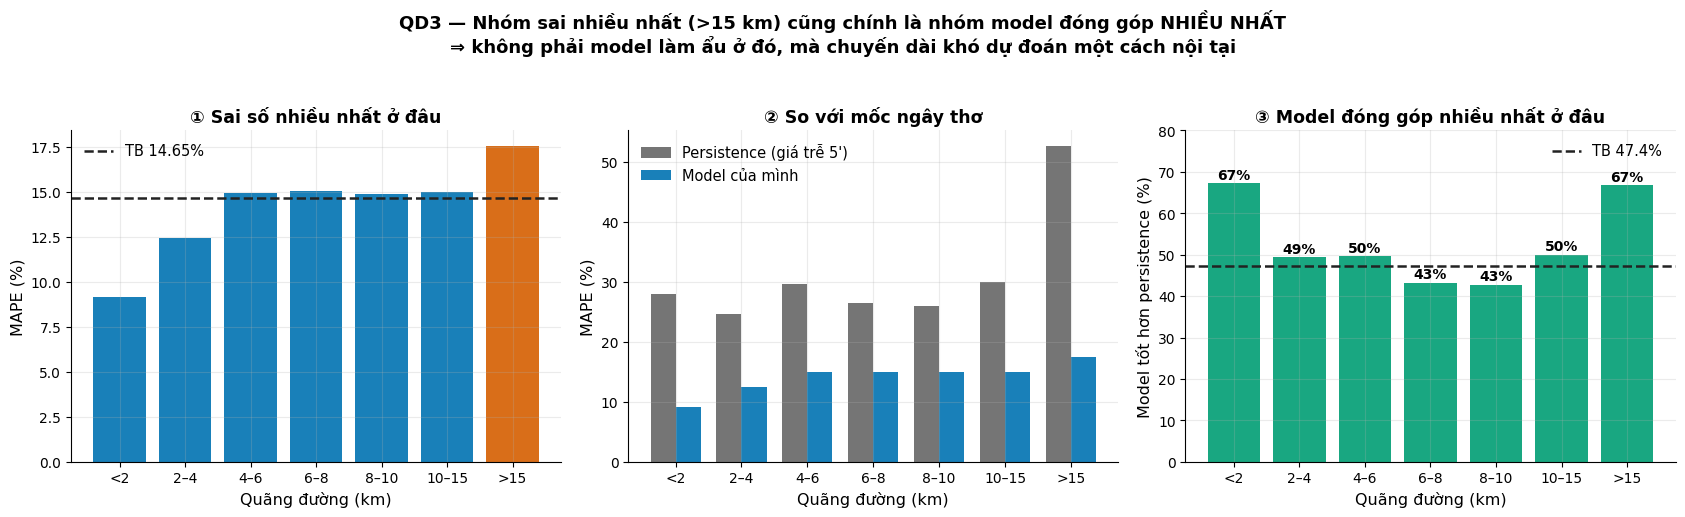

In [8]:
# ═════════ HINH QD3 — fail o dau, va o do co te that khong ═════════
gk = t.groupby("km", observed=True).agg(
    mape=("sai", "mean"), mape_ps=("sai_ps", "mean"), n=("sai", "size")).reindex(KMN)
gk["hon_ps"] = 1 - gk.mape / gk.mape_ps

fig, ax = plt.subplots(1, 3, figsize=(17, 5))
x = np.arange(len(KMN))

a = ax[0]
a.bar(x, gk.mape*100, color=[RED if v > t.sai.mean()*1.15 else BLUE for v in gk.mape], alpha=.9)
a.axhline(t.sai.mean()*100, color=INK, lw=1.8, ls="--", label=f"TB {t.sai.mean():.2%}")
a.set_xticks(x); a.set_xticklabels(KMN); a.set_xlabel("Quãng đường (km)")
a.set_ylabel("MAPE (%)"); a.set_title("① Sai số nhiều nhất ở đâu", fontweight="bold")
a.legend(frameon=False)

a = ax[1]
w = .38
a.bar(x - w/2, gk.mape_ps*100, w, color=MUT,  alpha=.9, label="Persistence (giá trễ 5')")
a.bar(x + w/2, gk.mape*100,    w, color=BLUE, alpha=.9, label="Model của mình")
a.set_xticks(x); a.set_xticklabels(KMN); a.set_xlabel("Quãng đường (km)")
a.set_ylabel("MAPE (%)"); a.set_title("② So với mốc ngây thơ", fontweight="bold")
a.legend(frameon=False)

a = ax[2]
a.bar(x, gk.hon_ps*100, color=GREEN, alpha=.9)
a.axhline((1 - t.sai.mean()/t.sai_ps.mean())*100, color=INK, lw=1.8, ls="--",
          label=f"TB {1-t.sai.mean()/t.sai_ps.mean():.1%}")
for i, v in enumerate(gk.hon_ps):
    a.text(i, v*100 + 1, f"{v:.0%}", ha="center", fontweight="bold", fontsize=10)
a.set_xticks(x); a.set_xticklabels(KMN); a.set_xlabel("Quãng đường (km)")
a.set_ylabel("Model tốt hơn persistence (%)"); a.set_ylim(0, 80)
a.set_title("③ Model đóng góp nhiều nhất ở đâu", fontweight="bold")
a.legend(frameon=False)

fig.suptitle("QD3 — Nhóm sai nhiều nhất (>15 km) cũng chính là nhóm model đóng góp NHIỀU NHẤT\n"
             "⇒ không phải model làm ẩu ở đó, mà chuyến dài khó dự đoán một cách nội tại",
             fontweight="bold", fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(HINH / "QD3_fail_o_dau.png")
plt.show()

**Đây là chỗ cần đọc kỹ, vì nó đảo ngược kết luận dễ đưa ra nhất.**

Nhìn panel ① một mình sẽ kết luận *"model làm ẩu ở chuyến dài, phải sửa chỗ đó"*. Nhưng panel ③
cho thấy chuyến `>15 km` là nơi model **vượt persistence tới 66,7%** — cao nhất trong mọi nhóm,
so với mức trung bình 47,4%.

⇒ Chuyến dài sai nhiều **không phải vì model kém ở đó**, mà vì giá chuyến dài **biến động nội tại
mạnh hơn**. Model đang làm tốt phần việc của nó; phần sai còn lại là độ khó thật của bài toán.

Hệ quả cho việc lập kế hoạch: **đừng đổ công vào "sửa chuyến dài"**. Muốn giảm sai số ở đó thì phải
có **thông tin mới** (cung–cầu theo tuyến, tình trạng giao thông thực tế), không phải chỉnh model
trên cùng bộ feature cũ.

## 5. Khoảng rộng vì thị trường ĐỘNG, hay vì nhiễu?

Hai câu hỏi trên đã đóng lại đường hiệu chỉnh. Nhưng còn một đề xuất tự nhiên chưa bị loại:

> *"Giá đối thủ biến động liên tục. Nếu quan sát nhanh hơn — rút độ trễ từ 30 phút xuống 5 phút —
> thì dự đoán sát hơn và khoảng hẹp lại."*

Nghe hợp lý, và **kiểm được trực tiếp**: dữ liệu có sẵn bốn mức độ trễ. Nếu độ rộng khoảng do thị
trường trôi thì nó phải **co lại rõ rệt** khi độ trễ ngắn đi.

In [9]:
# uc da bi loc con lag 5 o cell dau -> nap lai ban day du 4 lag
uc_all = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")

KQ_LAG = []
for lag in sorted(ut.requested_lag_minutes.unique()):
    c = uc_all[uc_all.requested_lag_minutes == lag].copy()
    x = ut[ut.requested_lag_minutes == lag].copy()
    c["res"] = (c.hybrid_pred - c.gia_that).abs() / c.hybrid_pred
    q = c.res.quantile(MUC)
    trong = (x.gia_that >= x.hybrid_pred*(1-q)) & (x.gia_that <= x.hybrid_pred*(1+q))
    KQ_LAG.append({
        "Độ trễ (phút)": int(lag),
        "MAPE model":    ((x.hybrid_pred - x.gia_that).abs() / x.gia_that).mean(),
        "MAPE persistence": ((x.persistence - x.gia_that).abs() / x.gia_that).mean(),
        "Nửa độ rộng":   q,
        "Coverage":      trong.mean()})

bl = pd.DataFrame(KQ_LAG)
bl.style.format({"MAPE model": "{:.2%}", "MAPE persistence": "{:.2%}",
                 "Nửa độ rộng": "±{:.2%}", "Coverage": "{:.2%}"}).hide(axis="index")

Độ trễ (phút),MAPE model,MAPE persistence,Nửa độ rộng,Coverage
5,14.65%,27.84%,±30.07%,89.81%
10,14.69%,28.03%,±30.05%,89.66%
15,14.74%,28.19%,±30.08%,89.54%
30,14.91%,28.67%,±30.19%,89.24%


**Đề xuất bị loại.** Rút độ trễ từ 30 phút xuống 5 phút chỉ cải thiện MAPE **0,26 điểm**, và độ
rộng khoảng gần như **không đổi** (±30,19% → ±30,07%, tức −0,4%).

Để so sánh: `persistence` — thứ *hoàn toàn* phụ thuộc độ tươi của giá quan sát — tệ đi **3,0%** khi
độ trễ dài ra. Nghĩa là phép đo có đủ độ nhạy để phát hiện tác động của độ trễ; nó chỉ cho thấy
**model gần như miễn nhiễm** với độ trễ.

⇒ Độ rộng ±30% **không phải** do thị trường trôi trong lúc chờ.

In [10]:
# Bien dong gia den tu dau: doc theo THOI GIAN hay ngang giua cac bao gia?
DATA = Path("../data/hcm_train_ready.parquet")
COLS_BD = ["target_request_id", "target_timestamp", "quote_distance", "quote_duration",
           "target_shown_price", "target_shown_multiplier", "requested_lag_minutes",
           "history_60m_price_mean", "history_60m_price_std", "history_60m_observation_count"]
bd = pd.read_parquet(DATA, columns=COLS_BD)
bd = bd[bd.requested_lag_minutes == 5].drop_duplicates("target_request_id").copy()
bd["base"] = bd.target_shown_price / bd.target_shown_multiplier
bd["gio"]  = bd.target_timestamp.dt.floor("h")
bd["km05"] = (bd.quote_distance // 0.5).astype(int)
bd["ph5"]  = (bd.quote_duration // 300).astype(int)      # quote_duration tinh bang GIAY

CV60 = (bd.history_60m_price_std / bd.history_60m_price_mean).replace([np.inf, -np.inf], np.nan)

def cv_trong_o(khoa):
    g = bd.groupby(khoa, observed=True).base.agg(["mean", "std", "size"])
    g = g[g["size"] >= 30]
    return float((g["std"] / g["mean"]).median()), len(g)

cv_km,  n1 = cv_trong_o(["km05", "ph5"])
cv_kmg, n2 = cv_trong_o(["km05", "ph5", "gio"])
gh = bd.groupby("gio").target_shown_multiplier.agg(["mean", "std", "size"])
gh = gh[gh["size"] >= 50]

print(f"Biến động giá quan sát trong cửa sổ 60 phút : CV {CV60.median():.1%} "
      f"(trung vị {bd.history_60m_observation_count.median():.0f} báo giá/cửa sổ)")
print(f"  ├─ cùng quãng đường + thời lượng          : CV {cv_km:.1%}  ({n1:,} ô)")
print(f"  └─ + cùng GIỜ                             : CV {cv_kmg:.1%}  ({n2:,} ô)")
print(f"\nHệ số nhân — phần thị trường thật sự động:")
print(f"  trong 1 giờ  : CV {(gh['std']/gh['mean']).median():.1%}")
print(f"  giữa các giờ : {gh['mean'].min():.3f} → {gh['mean'].max():.3f} "
      f"(biên độ {gh['mean'].max()/gh['mean'].min()-1:.1%})")

Biến động giá quan sát trong cửa sổ 60 phút : CV 24.9% (trung vị 63 báo giá/cửa sổ)
  ├─ cùng quãng đường + thời lượng          : CV 18.6%  (383 ô)
  └─ + cùng GIỜ                             : CV 18.5%  (6,620 ô)

Hệ số nhân — phần thị trường thật sự động:
  trong 1 giờ  : CV 7.3%
  giữa các giờ : 0.851 → 1.592 (biên độ 87.2%)


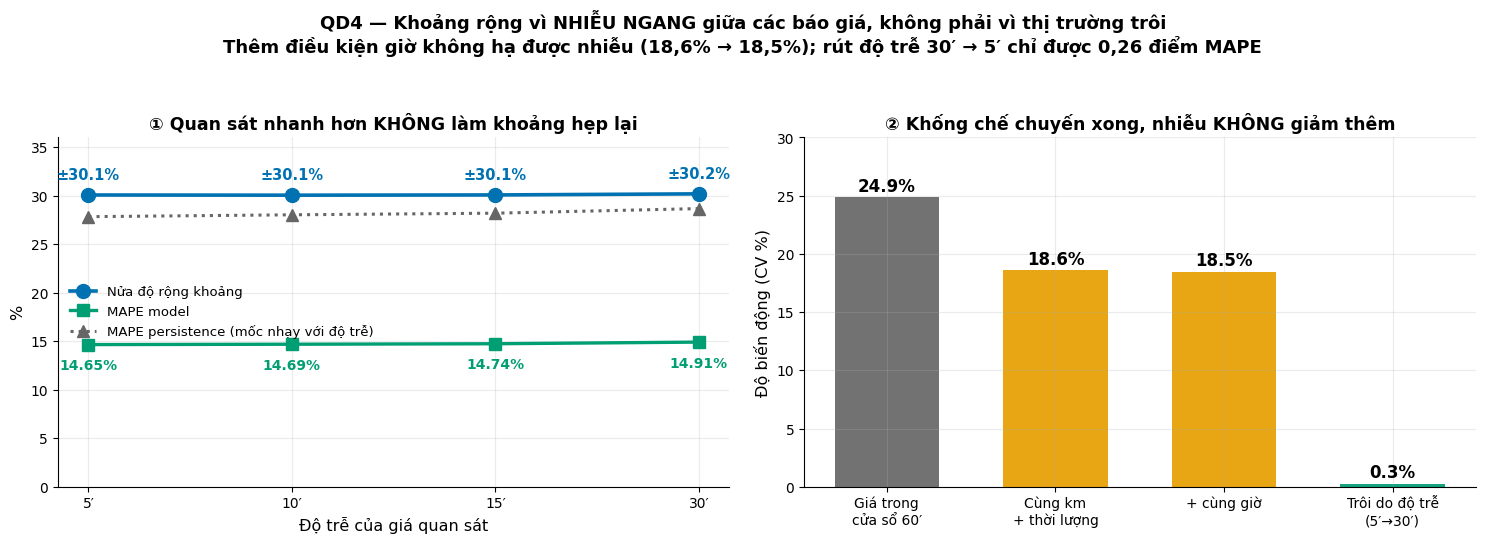

In [11]:
# ═════════ HINH QD4 — khoang rong vi nhieu ngang, khong phai vi thi truong troi ═════════
fig, ax = plt.subplots(1, 2, figsize=(15, 5.2))

a = ax[0]
x = np.arange(len(bl))
a.plot(x, bl["Nửa độ rộng"]*100, "o-", color=BLUE, lw=2.6, ms=10, label="Nửa độ rộng khoảng")
a.plot(x, bl["MAPE model"]*100,  "s-", color=GREEN, lw=2.4, ms=9,  label="MAPE model")
a.plot(x, bl["MAPE persistence"]*100, "^:", color=MUT, lw=2.2, ms=9,
       label="MAPE persistence (mốc nhạy với độ trễ)")
for i in x:
    a.annotate(f"±{bl['Nửa độ rộng'].iloc[i]:.1%}", (i, bl["Nửa độ rộng"].iloc[i]*100),
               textcoords="offset points", xytext=(0, 11), ha="center",
               fontsize=10.5, fontweight="bold", color=BLUE)
    a.annotate(f"{bl['MAPE model'].iloc[i]:.2%}", (i, bl["MAPE model"].iloc[i]*100),
               textcoords="offset points", xytext=(0, -18), ha="center",
               fontsize=10, fontweight="bold", color=GREEN)
a.set_xticks(x); a.set_xticklabels([f"{v}′" for v in bl["Độ trễ (phút)"]])
a.set_xlabel("Độ trễ của giá quan sát"); a.set_ylabel("%")
a.set_ylim(0, 36)
a.set_title("① Quan sát nhanh hơn KHÔNG làm khoảng hẹp lại", fontweight="bold")
a.legend(frameon=False, fontsize=9.5, loc="center left")

a = ax[1]
ten = ["Giá trong\ncửa sổ 60′", "Cùng km\n+ thời lượng", "+ cùng giờ", "Trôi do độ trễ\n(5′→30′)"]
val = [CV60.median()*100, cv_km*100, cv_kmg*100,
       (bl["MAPE model"].iloc[-1] - bl["MAPE model"].iloc[0])*100]
mau = [MUT, ORANGE, ORANGE, GREEN]
a.bar(ten, val, color=mau, alpha=.92, width=.62)
for i, v in enumerate(val):
    a.text(i, v + .5, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=12)
a.set_ylabel("Độ biến động (CV %)"); a.set_ylim(0, 30)
a.set_title("② Khống chế chuyến xong, nhiễu KHÔNG giảm thêm", fontweight="bold")

fig.suptitle("QD4 — Khoảng rộng vì NHIỄU NGANG giữa các báo giá, không phải vì thị trường trôi\n"
             "Thêm điều kiện giờ không hạ được nhiễu (18,6% → 18,5%); "
             "rút độ trễ 30′ → 5′ chỉ được 0,26 điểm MAPE",
             fontweight="bold", fontsize=13, y=1.04)
fig.tight_layout()
fig.savefig(HINH / "QD4_bien_dong_vs_khoang.png")
plt.show()

**Đọc hình QD4:**

- **Panel ①** — ba đường gần như phẳng theo độ trễ. Nếu khoảng rộng do thị trường trôi thì đường
  xanh phải dốc xuống rõ khi độ trễ ngắn lại. Nó không.
- **Panel ②** — giá quan sát trong cửa sổ 60 phút dao động **CV 24,9%**. Nhưng phần lớn dao động đó
  là do **các chuyến khác nhau**, không phải do giá đổi theo thời gian: khống chế quãng đường và
  thời lượng thì còn **18,6%**, và thêm điều kiện **cùng giờ** hầu như không giảm nữa (**18,5%**).

**Phân biệt hai loại biến động — đây là mấu chốt:**

| Loại | Độ lớn | Model xử lý được không |
|---|---:|---|
| **Nhịp thị trường** (hệ số nhân theo giờ) | biên độ **87,2%** giữa các giờ | ✅ Có — model đạt MAPE **1,42%** ở tầng này |
| **Nhiễu ngang** (giữa các báo giá cùng bối cảnh) | CV **18,5%** | ❌ Không — không feature nào giải thích được |
| **Trôi theo thời gian** (5′ → 30′) | **0,26 điểm** MAPE | — quá nhỏ để đáng xử lý |

Thị trường **có** động, và động rất mạnh — hệ số nhân chạy từ 0,851 tới 1,592 giữa các giờ. Nhưng
model **đã bắt được** nhịp đó. Phần còn lại là nhiễu ngang, và nó không co lại dù khống chế thêm
điều kiện nào.

> **Kết luận mục 5:** khoảng ±30% không phải cái giá phải trả cho việc quan sát trễ. Nó là ảnh phản
> chiếu của nhiễu ngang giữa các báo giá. **Cập nhật giá nhanh hơn không phải hướng đi.**

## 6. Đổi hẳn kiến trúc thì sao — kết quả transformer

Ba mục trên đóng lại đường *hiệu chỉnh* và đường *quan sát nhanh hơn*. Còn một khả năng: **model
hiện tại chưa đủ mạnh**, cần kiến trúc khác.

Giả thuyết cụ thể: model nén 60 phút lịch sử giá thành **ba con số** `mean · std · slope`. Hình
dạng chuỗi bị vứt đi — một chuỗi tăng đều và một chuỗi giật cục có thể cho ba con số gần như y hệt.
**Transformer đọc thẳng chuỗi** nên phân biệt được.

Đã chạy đầy đủ trên Kaggle (GPU T4, 90.792 tham số, train riêng từng tháng, test 864.360 chuyến):

In [12]:
TF = pd.DataFrame([
    {"Model": "Hybrid (GBM 2 tầng)", "MAE": 18048, "MAPE": .1474, "R2": .73},
    {"Model": "Transformer (chuỗi 32 báo giá)", "MAE": 18008, "MAPE": .1480, "R2": .7326},
    {"Model": "— Persistence (mốc)", "MAE": 33683, "MAPE": .2818, "R2": .0191},
])
TF["Chênh MAE"]  = TF.MAE / TF.MAE.iloc[0] - 1
TF["Chênh MAPE"] = (TF.MAPE - TF.MAPE.iloc[0]) * 100
TF.style.format({"MAE": "{:,.0f}đ", "MAPE": "{:.2%}", "R2": "{:.4f}",
                 "Chênh MAE": "{:+.2%}", "Chênh MAPE": "{:+.2f} điểm"}).hide(axis="index")

Model,MAE,MAPE,R2,Chênh MAE,Chênh MAPE
Hybrid (GBM 2 tầng),"18,048đ",14.74%,0.7300,+0.00%,+0.00 điểm
Transformer (chuỗi 32 báo giá),"18,008đ",14.80%,0.7326,-0.22%,+0.06 điểm
— Persistence (mốc),"33,683đ",28.18%,0.0191,+86.63%,+13.44 điểm


**Hai metric đi ngược nhau — đây là hoà, không phải thắng:**

| | Hybrid | Transformer | |
|---|---:|---:|---|
| MAE | 18.048đ | **18.008đ** | transformer tốt hơn **0,22%** |
| MAPE | **14,74%** | 14,80% | transformer tệ hơn **0,06 điểm** |

MAE ưu ái chuyến đắt, MAPE ưu ái chuyến rẻ. Hai metric lệch chiều nghĩa là hai model chỉ **phân bổ
sai số khác nhau**, không phải một cái giỏi hơn. Chênh 0,22% cũng nằm gọn trong dải **1,9%** giữa
bốn thuật toán cây.

Và **band `>300k` vẫn tệ nhất** (MAPE 18,06% so với 18,55% của Hybrid) — kiến trúc khác hẳn, cùng
một chỗ hỏng.

> **Kết luận mục 6:** transformer đọc thẳng chuỗi 32 báo giá **không moi thêm được thông tin nào**
> so với ba con số tổng hợp. Không đưa vào pipeline — đổi 0,22% MAE lấy một model cần GPU, train gấp
> 4 lần thời gian, và phải lưu kèm thống kê chuẩn hoá khi phục vụ.
>
> Giá trị của kết quả này nằm ở chỗ khác: **một họ model hoàn toàn khác cũng dừng ở cùng mức** ⇒
> nút thắt là dữ liệu, không phải sức chứa của model.

## Kết luận — trả lời thẳng câu hỏi của mentor

### **Phải improve model. Đường giảm uncertainty đã cạn.**

Ba phép đo, ba khả năng bị đóng lại:

| Đo gì | Kết quả | Đóng lại điều gì |
|---|---|---|
| 4 cách hiệu chỉnh × 4 chiều | Tốt nhất **−0,37%** độ rộng | Hiệu chỉnh lại **không** làm hẹp khoảng |
| Dự đoán độ lớn sai số | Tương quan hạng **0,05** | Không thể cấp khoảng hẹp cho chuyến dễ — vì không biết chuyến nào dễ |
| Trần lý thuyết | **−51%** nếu biết trước độ khó | Dư địa có thật, nhưng **thông tin cần thiết không nằm trong dữ liệu đang có** |

Khoảng ±30,1% không phải lỗi hiệu chỉnh — nó là ảnh phản chiếu trung thực của MAPE 14,65%.
**Muốn khoảng hẹp thì model phải sai ít hơn.** Không có đường tắt.

### Vẫn nên bật Mondrian ngay — nhưng vì lý do khác

Không phải để hẹp, mà để **đều**. Chi phí vài giờ, không train lại:

| | Toàn cục | Mondrian |
|---|---:|---:|
| Lệch coverage giữa các band giá | 8,62 điểm | **1,46 điểm** |
| Lệch coverage giữa các nhóm quãng đường | 12,61 điểm | **2,53 điểm** |
| Nửa độ rộng trung bình | ±30,07% | ±30,11% |

Nhóm `>300k` và `>15 km` — chuyến **đắt tiền nhất**, nơi sai một khoảng tin cậy tốn nhiều nhất —
đang bị hụt gần 8 điểm coverage dưới hiệu chỉnh toàn cục. Đây là lỗi **có thật, đã đo được, và
sửa gần như miễn phí**.

### Model fail ở đâu — câu trả lời chính xác

| | |
|---|---|
| **Chiều gây lệch mạnh nhất** | Quãng đường (η² 0,0106). MAPE 9,16% → **17,52%** |
| **Chiều gần như vô can** | Giờ · thời tiết · cao điểm · cuối tuần (η² ≤ 0,0001, biên độ ≤ 0,4 điểm) |
| **Nhưng** | `>15 km` cũng là nơi model **vượt persistence 66,7%** — cao nhất |
| **Nên đọc là** | Không phải "model làm ẩu ở chuyến dài" mà "chuyến dài khó một cách nội tại" |

### Việc nên làm tiếp, theo thứ tự

1. **Bật Mondrian** (vài giờ) — sửa lệch coverage 12,6 → 2,5 điểm. Làm ngay.
2. **Tìm thông tin mới**, không phải chỉnh model cũ. Sai số còn lại không giải thích được bằng bất
   kỳ feature nào đang có — chứng cứ là tương quan hạng 0,05 ở mục 3. Ứng viên: tín hiệu cung–cầu
   theo tuyến, tình trạng giao thông thực tế.
3. **Encode causality** — xem `03_CETERIS_PARIBUS_VA_CAUSALITY`. Đó là hướng duy nhất trong ba
   hướng vừa cải thiện được sai số vừa trả lời được câu what-if của mentor.

### Liên quan

| Notebook | Nội dung |
|---|---|
| `model/uncertainty/06_thu_hep_khoang` | Bản đào sâu: 5 cách × 7 nhóm, phân tích vì sao mỗi cách thất bại |
| `model/evaluation/09_chan_doan_model` | Bản đào sâu: 10 chiều, thiên lệch hệ thống, nhóm ngoại lai |
| `01_BA_KICH_BAN` | Vì sao độ rộng đều giữa cao điểm và giờ thường |
| `03_CETERIS_PARIBUS_VA_CAUSALITY` | Đường đi tiếp: model học cơ chế thay vì bám giá quan sát |